# Predictive modeling for short-term solar power forecasting and anomaly detection using Deep Neural Network algorithm

---

## Project Information

**Authors**:
- Geronimo Welter Lapinig
- Victor Rusu
- Sankruththian Senathirajah
  
**Course**: SCS 3253-093 Machine Learning  
**Instructor**: Dr. Sebastian Maurice  
**Institution**: University of Toronto School of Continuing Studies  
**Submission Date**: April 2026  
**Purpose**:  


![University Logo](https://learn.utoronto.ca/themes/custom/de_theme/logo.svg)


---
## Introduction

The growing adoption of solar energy systems has increased the need for accurate and reliable forecasting of power generation, as well as timely detection of system anomalies. Short-term solar power forecasting plays a critical role in optimizing grid operations, improving energy management, and ensuring the stability of renewable energy integration. At the same time, anomaly detection is essential for identifying faults, inefficiencies, or unexpected behavior in photovoltaic (PV) systems that may impact performance.

In this project, we develop a data-driven framework for short-term solar power forecasting and anomaly detection using real-world data from the PVDAQ Systems 2105 and 2107 datasets, provided through the Open Energy Data Initiative (OpenEDI). These datasets contain high-resolution time-series measurements, including solar irradiance, ambient temperature, and AC power output, enabling a comprehensive analysis of environmental and system-level factors influencing solar energy production.

To model the complex, nonlinear relationships inherent in solar generation data, we employ <b> deep neural networks (DNNs) </b> for predictive analytics. The model is trained to forecast short-term AC power output based on historical observations and engineered features, capturing temporal patterns such as daily and seasonal cycles. In addition, anomaly detection is performed by analyzing deviations between predicted and actual power output, allowing the identification of irregular system behavior.

The objective of this study is to evaluate the effectiveness of deep learning techniques in improving forecasting accuracy while simultaneously enabling robust anomaly detection. Model performance is assessed using standard regression metrics such as Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE), along with qualitative analysis of detected anomalies. This work contributes toward building intelligent, scalable solutions for monitoring and optimizing solar energy systems in real-world applications.

---
## Dataset Description

This study utilizes photovoltaic (PV) system data obtained from the Open Energy Data Initiative (OpenEDI), specifically the PVDAQ Systems 2105 and 2107 datasets. These datasets consist of high-frequency time-series measurements collected from operational solar installations, providing detailed insights into system performance and environmental conditions. Key variables include timestamp (<code>measured_on</code>), solar irradiance components such as Global Horizontal Irradiance (GHI) and Direct Normal Irradiance (DNI), ambient temperature, wind characteristics, and AC power output. The AC power output serves as the target variable for forecasting tasks.

The data spans multiple years and contains natural variability due to weather patterns, seasonal effects, and operational changes. Additionally, the dataset includes missing values, noise, and periods of irregular measurements, which necessitate careful preprocessing before modeling.

### Dataset Overview

The working modeling table was constructed from the PVDAQ **2107** meter, irradiance, and environment files, then enriched with solar-position variables derived from the timestamp. After merging and cleaning, the final time-series table contains **105,192 observations** and **9 core variables**, indexed at **15-minute intervals** from **January 1, 2020 to December 31, 2022**.

The target variable used for forecasting is **AC power output** (`ac_output_kw`). The main predictor variables include **plane-of-array irradiance**, **ambient temperature**, **wind speed**, **wind direction**, and solar geometry variables such as **solar elevation**, **apparent elevation**, **zenith**, and **azimuth**. There are **0% missing values** in the final merged table, making it suitable for downstream forecasting and anomaly detection experiments.

Table 1 summarizes the dataset used in the implementation notebook.

| Component | Value |
|---|---:|
| Source used in implementation notebook | PVDAQ System 2107 |
| Data sources merged | Meter, irradiance, and environment files |
| Time span | 2020-01-01 to 2022-12-31 |
| Sampling frequency | 15 minutes |
| Final merged rows | 105,192 |
| Core variables | 9 |
| Missing-value rate in merged table | 0.0% |
| Daytime-only rows (`poa_irradiance > 0`) | 55,805 |
| Training rows (2020-2021) | 70,160 |
| Test rows (2022) | 35,032 |
| Final daytime supervised training rows | 36,219 |
| Final daytime supervised test rows | 19,574 |

**Core variables in the merged dataset:** `ac_output_kw`, `poa_irradiance`, `ambient_temp_f`, `wind_speed_mph`, `wind_direction_deg`, `solar_elevation`, `solar_apparent_elevation`, `solar_zenith`, and `solar_azimuth`.

### Machine Learning Algorithms

- #### Deep Neural Networks (DNNs)


Deep neural networks are supervised learning models composed of many interconnected artificial neurons arranged in layers. A DNN is called *deep* because it contains multiple hidden layers between the input and output layers, allowing it to learn increasingly complex representations of the data. In this project, the model is used for **short-term solar power forecasting**, where the goal is to learn the nonlinear relationship between environmental measurements and AC power output.


At the neuron level, each unit receives an input vector, applies a weighted sum, adds a bias term, and then passes the result through a nonlinear activation function:

$$z = w_1x_1 + w_2x_2 + \, \cdots \, + w_nx_n + b$$

$$a = \sigma(z)$$

where $x_1, x_2, \dots, x_n$ are the input features, $w_1, w_2, \dots, w_n$ are the learned weights, $b$ is the bias, and $\sigma(\cdot)$ is the activation function. Without nonlinear activations, stacking many layers would still behave like a simple linear model; with them, the network can capture more complex patterns in solar generation data such as weather-driven fluctuations, seasonal behavior, and feature interactions.


A typical feedforward DNN for tabular regression consists of three main parts:

- **Input layer**: receives the engineered predictor variables, such as irradiance, temperature, wind-related variables, and temporal features.
- **Hidden layers**: transform the input into more useful internal representations through repeated linear and nonlinear operations.
- **Output layer**: produces the final prediction, which in this project is the forecasted solar AC power output.

The overall mapping learned by the model can be summarized as:

$$\hat{y} = f(x; \theta)$$

where $x$ is the input feature vector, $\theta$ represents all trainable parameters (weights and biases), and $\hat{y}$ is the predicted output.


During training, data passes through the network in a **forward pass** to generate predictions. The error between predicted and actual power output is then measured using a loss function. Since this project is a regression task, the most natural choice is the **Mean Squared Error (MSE)** loss:

$$L = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$$

The network parameters are updated through **backpropagation**, which computes gradients of the loss with respect to the weights, followed by an optimizer such as Adam or RMSProp that adjusts the parameters to reduce prediction error over time.


Activation functions play a central role in DNN performance because they control how information and gradients move through the model. In practice, **ReLU** is commonly used in hidden layers because it is simple, fast, and effective for deep architectures, while the output layer for regression is usually linear so that the model can predict continuous power values. The training and optimization notes also show that activation choices such as Leaky ReLU or ELU may improve convergence and stability in some settings, but ReLU remains a strong baseline for dense neural networks.


Model optimization is also influenced by initialization and training strategy. Proper weight initialization helps keep activations stable across layers, while the choice of optimizer affects convergence speed and generalization. For ReLU-based networks, **He initialization** is often preferred because it is designed to maintain useful signal flow in deeper models. In addition, techniques such as adaptive optimizers, learning-rate scheduling, and **early stopping** can improve training efficiency and reduce overfitting by stopping the model once validation performance no longer improves.


For this solar forecasting project, deep neural networks are appropriate because the relationship between meteorological variables and photovoltaic power output is highly nonlinear and influenced by interacting factors. Unlike simpler linear or probabilistic methods, a DNN can learn layered feature representations that capture complex dependencies in irradiance, temperature, time-of-day effects, and changing operating conditions across the PVDAQ systems.


**Strengths**:
- Learns complex nonlinear relationships automatically
- Works well with large multivariate tabular datasets
- Can model interactions among weather, temporal, and system variables
- Flexible enough to support both forecasting and residual-based anomaly detection

**Limitations**:
- Requires more tuning than simpler models
- Training can be sensitive to learning rate, initialization, and architecture choices
- Less interpretable than baseline statistical models
- Performance depends strongly on data quality, feature engineering, and validation strategy




---



## Initial Quality Checks

Before moving into feature engineering and model development, the combined PVDAQ time-series data was reviewed to confirm that the dataset was structurally sound and suitable for short-term forecasting. This stage focused on three practical questions: **Is the timeline clean? Are the variables complete? Does the power signal look realistic over time?**

These checks matter because even a strong deep neural network can learn the wrong patterns if the raw data contains hidden gaps, index problems, or unrecognized operational shifts. The goal here is not only to report summary statistics, but to build confidence that the dataset behaves like a real solar power system before it is passed into the learning pipeline.



## Structural Overview

The implementation notebook shows that the merged dataset contains **105,192 time-indexed observations** and **9 numerical variables**, covering the period from **January 2020 through December 2022** at **15-minute intervals**. The index is stored as a `DatetimeIndex` named `measured_on`, and it is sorted chronologically, which is essential for time-series forecasting and for later creating lag-based features.


In [ ]:

import pandas as pd
from IPython.display import display

quality_overview = pd.DataFrame([
    ["Observation window", "2020-01-01 to 2022-12-31"],
    ["Sampling frequency", "15-minute intervals"],
    ["Total rows", "105,192"],
    ["Total columns", "9"],
    ["Index name", "measured_on"],
    ["Index type", "DatetimeIndex"],
    ["Chronologically sorted", "Yes"],
    ["Training split", "2020-2021 (70,160 rows)"],
    ["Test split", "2022 (35,032 rows)"]
], columns=["Quality check item", "Finding"])

display(quality_overview)


,Quality check item,Finding
0,Observation window,2020-01-01 to 2022-12-31
1,Sampling frequency,15-minute intervals
2,Total rows,"105,192"
3,Total columns,9
4,Index name,measured_on
5,Index type,DatetimeIndex
6,Chronologically sorted,Yes
7,Training split,"2020-2021 (70,160 rows)"
8,Test split,"2022 (35,032 rows)"



The data profile is a good fit for supervised forecasting. The number of observations is large enough to support deep learning, while the explicit train-test split by time preserves the real-world forecasting setting: the model learns from earlier years and is evaluated on a future year rather than on randomly shuffled records.



## Daytime Shape and Seasonal Pattern

To make the quality-check section more informative, the implementation notebook also looked at the structure of **daytime-only power output**. The heatmap below summarizes average AC power by **hour of day** and **month of year**, which makes both diurnal and seasonal behavior visible in a single figure.


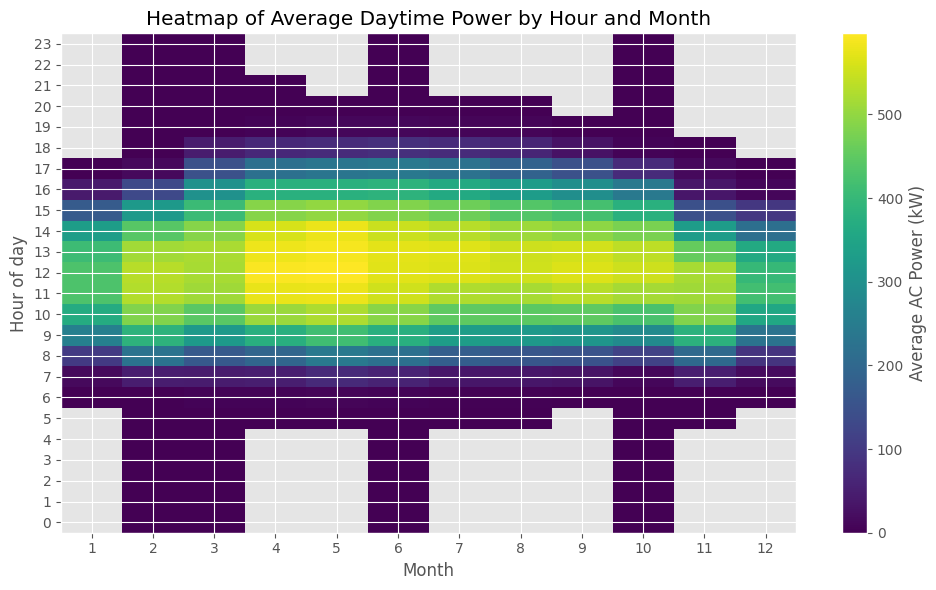

In [ ]:
# Creative visual imported from the implementation notebook: month-by-hour heatmap of average daytime AC power.


This heatmap tells a compact story about the dataset. Power output concentrates in the middle daylight hours, as expected, while the strength and width of that band vary across the calendar year. That pattern supports the choice of a deep neural network because the forecasting task is clearly nonlinear and depends on interacting temporal effects such as season, solar angle, irradiance, and time of day.


Overall, the initial quality assessment suggests that the PVDAQ dataset is in strong condition for predictive modeling. The timeline is ordered correctly, the selected variables are complete, the train-test split respects time, and the target signal exhibits believable solar behavior with both daily and seasonal structure. These findings justify proceeding to feature engineering, normalization, and deep neural network training with confidence that the core dataset is stable enough for forecasting and anomaly analysis.




---



## Structured Preprocessing and Feature Engineering

This section summarizes the main preprocessing workflow used in the implementation notebook. The goal was to organize the raw solar data into a cleaner supervised learning format, reduce leakage, and create features that help the model understand both current environmental conditions and recent system behavior.

A key improvement in this stage was the use of **structured feature groups** instead of treating all columns the same way. The notebook separates weather, solar geometry, calendar, cyclical, lag, and rolling features so that the modeling pipeline is easier to interpret, debug, and reuse.

### Feature Columns by Group

The implementation notebook organizes the model inputs into meaningful groups. This makes it easier to understand what type of information is being passed into the forecasting model and why each group matters.

In [ ]:
import pandas as pd
from IPython.display import display

# Feature groups adapted from the implementation notebook
feature_colsg = {
    "weather": [
        "poa_irradiance",
        "ambient_temp_f",
        "wind_speed_mph",
        "wind_direction_deg",
    ],
    "solar_geometry": [
        "solar_elevation",
        "solar_apparent_elevation",
        "solar_zenith",
        "solar_azimuth",
    ],
    "time_raw": [
        "hour",
        "day_of_week",
        "day_of_year",
        "month",
        "week_of_year",
        "year",
    ],
    "time_cyclical": [
        "hour_sin",
        "hour_cos",
        "doy_sin",
        "doy_cos",
    ],
    "wind_cyclical": [
        "wind_dir_sin",
        "wind_dir_cos",
    ],
    "lags": [
        "ac_output_kw_lag1",
        "ac_output_kw_lag4",
        "ac_output_kw_lag8",
        "poa_irradiance_lag1",
        "poa_irradiance_lag4",
    ],
    "rolling_means": [
        "ac_output_kw_roll4",
        "ac_output_kw_roll8",
        "poa_irradiance_roll4",
        "poa_irradiance_roll8",
    ],
    "rolling_std": [
        "ac_output_kw_std8",
    ],
}

feature_group_table = pd.DataFrame({
    "Feature Group": list(feature_colsg.keys()),
    "Number of Columns": [len(v) for v in feature_colsg.values()],
    "Example Columns": [", ".join(v[:3]) + ("..." if len(v) > 3 else "") for v in feature_colsg.values()]
})

display(feature_group_table)

,Feature Group,Number of Columns,Example Columns
0,weather,4,"poa_irradiance, ambient_temp_f, wind_speed_mph..."
1,solar_geometry,4,"solar_elevation, solar_apparent_elevation, sol..."
2,time_raw,6,"hour, day_of_week, day_of_year..."
3,time_cyclical,4,"hour_sin, hour_cos, doy_sin..."
4,wind_cyclical,2,"wind_dir_sin, wind_dir_cos"
5,lags,5,"ac_output_kw_lag1, ac_output_kw_lag4, ac_outpu..."
6,rolling_means,4,"ac_output_kw_roll4, ac_output_kw_roll8, poa_ir..."
7,rolling_std,1,ac_output_kw_std8


### Why lag features were added

**Lag features** store previous observations from the time series. For example, `ac_output_kw_lag1` uses the most recent past power value, while `ac_output_kw_lag4` and `ac_output_kw_lag8` represent earlier history. These variables help the model learn short-term persistence, which is very important in solar forecasting because current power output is often strongly related to recent power output.

In the notebook, lag features were created from the **original observed series**, not from the shifted future target. This matters because it prevents the model from accidentally seeing information from the future.

### Why rolling features were added

**Rolling features** summarize recent history over a moving window. For instance, `ac_output_kw_roll4` computes the mean over the recent past, and `ac_output_kw_std8` measures short-term variability. These features help smooth noisy readings and give the model a compact view of local trends and fluctuations.

For this project, rolling features are useful because solar power can change quickly with cloud cover, irradiance variation, and local weather. A rolling mean captures the short-term trend, while a rolling standard deviation highlights instability or rapid change.

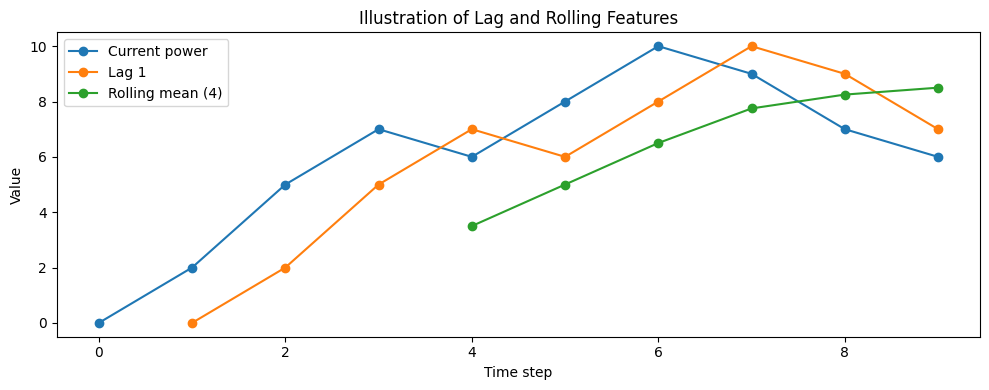

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Simple visual explanation of lag and rolling features
example = pd.DataFrame({
    "power_output": [0, 2, 5, 7, 6, 8, 10, 9, 7, 6]
})

example["lag_1"] = example["power_output"].shift(1)
example["rolling_mean_4"] = example["power_output"].shift(1).rolling(window=4).mean()

plt.figure(figsize=(10, 4))
plt.plot(example.index, example["power_output"], marker="o", label="Current power")
plt.plot(example.index, example["lag_1"], marker="o", label="Lag 1")
plt.plot(example.index, example["rolling_mean_4"], marker="o", label="Rolling mean (4)")
plt.title("Illustration of Lag and Rolling Features")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

### Final supervised dataset structure

After feature engineering, the notebook restricted the data to the study window and kept daytime rows for the forecasting setup. The final supervised dataset included weather variables, solar geometry, raw calendar variables, cyclical encodings, lag features, and rolling statistics, with the target defined as **1-hour-ahead AC power output**.

Overall, this preprocessing stage transformed the raw PVDAQ time-series data into a more informative and model-ready representation. It also improved the project structure by making the workflow more reusable for later models such as XGBoost or deep neural networks.

---
## Exploratory Data Analysis

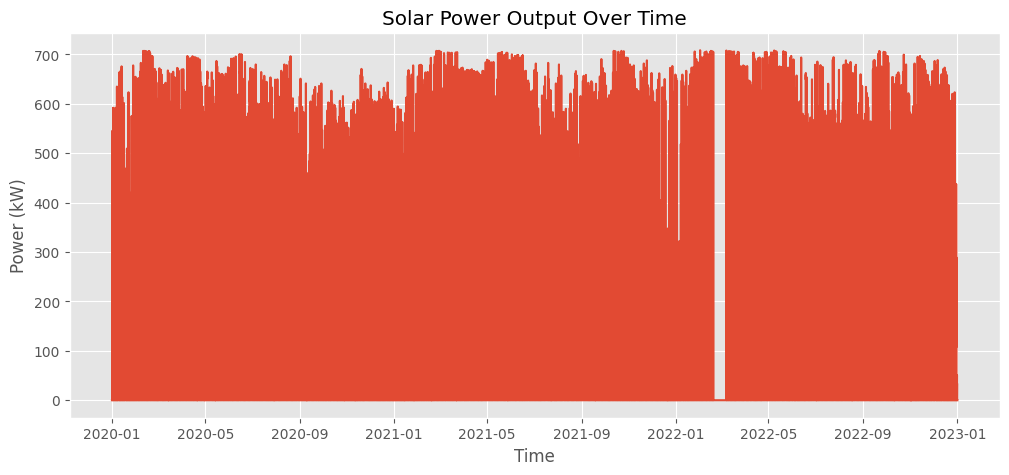

The Solar Power Output Over Time plot shows how the system’s power generation varies between 2020 and 2022, with output typically ranging between about 550 kW and 720 kW during active production periods. The fluctuations reflect normal changes in solar conditions such as cloud cover, seasonal variation, and daily irradiance patterns. A noticeable drop to near zero around early 2022 likely indicates missing data, maintenance downtime, or a temporary system outage.

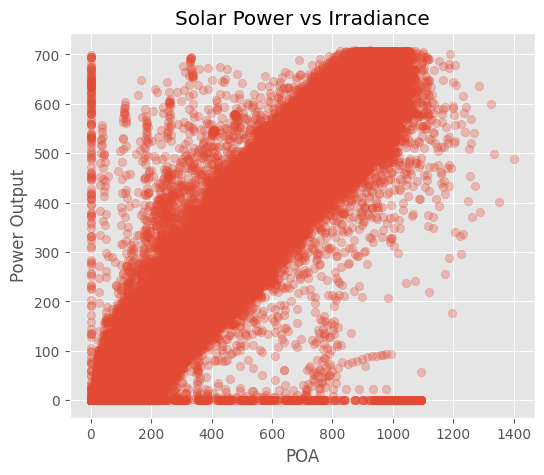

The Solar Power vs Irradiance scatter plot shows a strong positive relationship between plane-of-array (POA) irradiance and power output, indicating that higher sunlight levels generally produce higher power generation. As irradiance increases, the power output rises and eventually begins to level off near the system’s maximum capacity (around 700 kW). The points near zero power across different irradiance levels likely represent nighttime values, sensor noise, or system downtime.

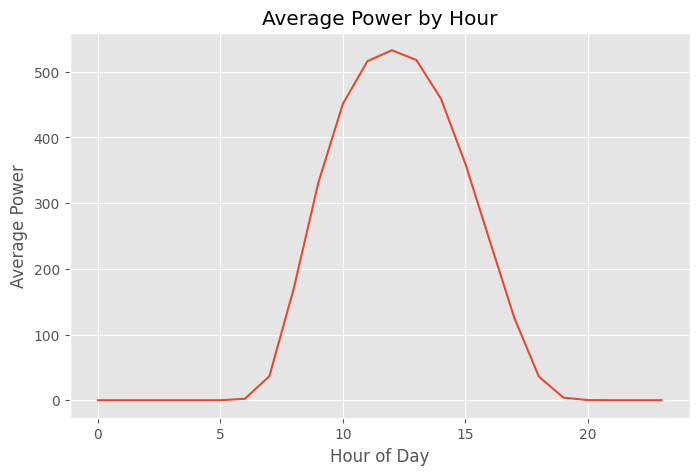

The Average Power by Hour plot shows the typical daily solar generation pattern of the system. Power output begins increasing in the morning around 7–8 AM, peaks around noon to early afternoon, and then gradually declines toward the evening as sunlight decreases. This bell-shaped curve reflects the natural daily cycle of solar irradiance and confirms that the system produces the most energy during midday hours.

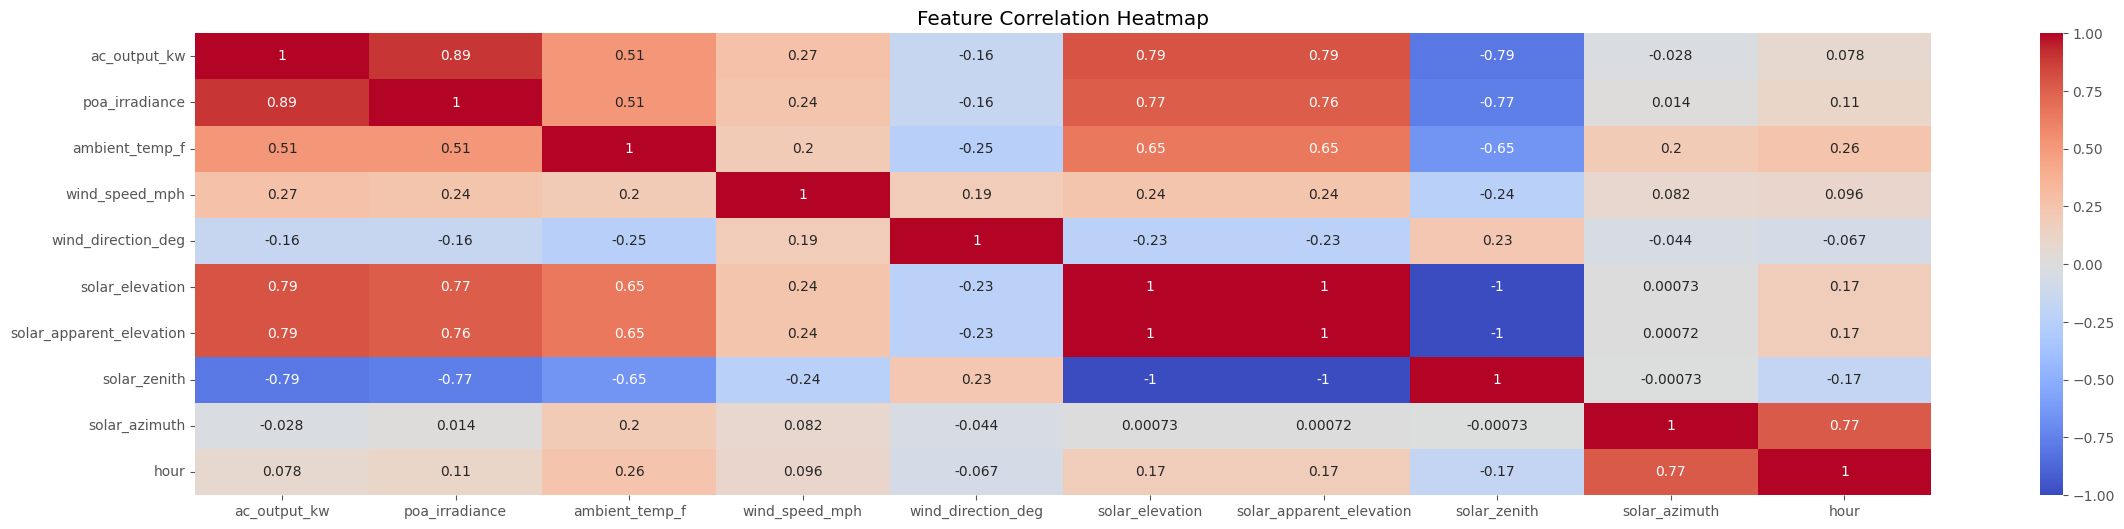


--- Correlation Matrix ---


,ac_output_kw,poa_irradiance,ambient_temp_f,wind_speed_mph,wind_direction_deg,solar_elevation,solar_apparent_elevation,solar_zenith,solar_azimuth,hour
ac_output_kw,1.000000,0.892785,0.514801,0.269701,-0.161746,0.792569,0.792242,-0.792569,-0.028358,0.077505
poa_irradiance,0.892785,1.000000,0.509519,0.244211,-0.161215,0.765199,0.764887,-0.765199,0.013920,0.107026
ambient_temp_f,0.514801,0.509519,1.000000,0.200232,-0.252982,0.652899,0.652757,-0.652899,0.197592,0.256699
wind_speed_mph,0.269701,0.244211,0.200232,1.000000,0.189198,0.242476,0.242406,-0.242476,0.082072,0.095719
wind_direction_deg,-0.161746,-0.161215,-0.252982,0.189198,1.000000,-0.231546,-0.231504,0.231546,-0.044472,-0.067201
solar_elevation,0.792569,0.765199,0.652899,0.242476,-0.231546,1.000000,0.999999,-1.000000,0.000733,0.174645
solar_apparent_elevation,0.792242,0.764887,0.652757,0.242406,-0.231504,0.999999,1.000000,-0.999999,0.000723,0.174688
solar_zenith,-0.792569,-0.765199,-0.652899,-0.242476,0.231546,-1.000000,-0.999999,1.000000,-0.000733,-0.174645
solar_azimuth,-0.028358,0.013920,0.197592,0.082072,-0.044472,0.000733,0.000723,-0.000733,1.000000,0.768800
hour,0.077505,0.107026,0.256699,0.095719,-0.067201,0.174645,0.174688,-0.174645,0.768800,1.000000


The Feature Correlation Heatmap illustrates the relationships between solar power output and several environmental variables. Power output shows a very strong positive correlation with POA irradiance (0.89), indicating that sunlight intensity is the main driver of solar generation, while ambient temperature has a moderate correlation (0.51). Other variables such as wind speed, wind direction, and hour show relatively weak relationships with power output, suggesting they have a smaller influence on the system’s energy production.

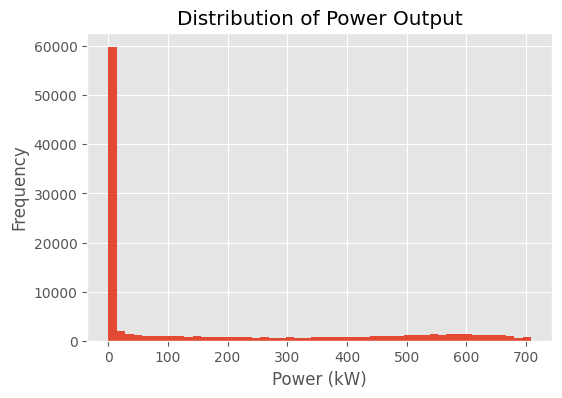

The Distribution of Power Output histogram shows that most observations occur near zero power, which corresponds primarily to nighttime periods when solar panels do not generate electricity. The large concentration near zero is also influenced by the data gap visible in the time-series plot between early 2022 and mid-2022, where power values appear to drop to zero. As power increases, the distribution spreads across higher values up to about 700 kW, representing normal daytime solar production levels.

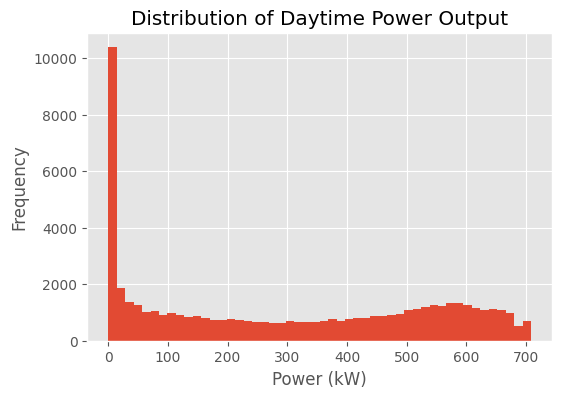

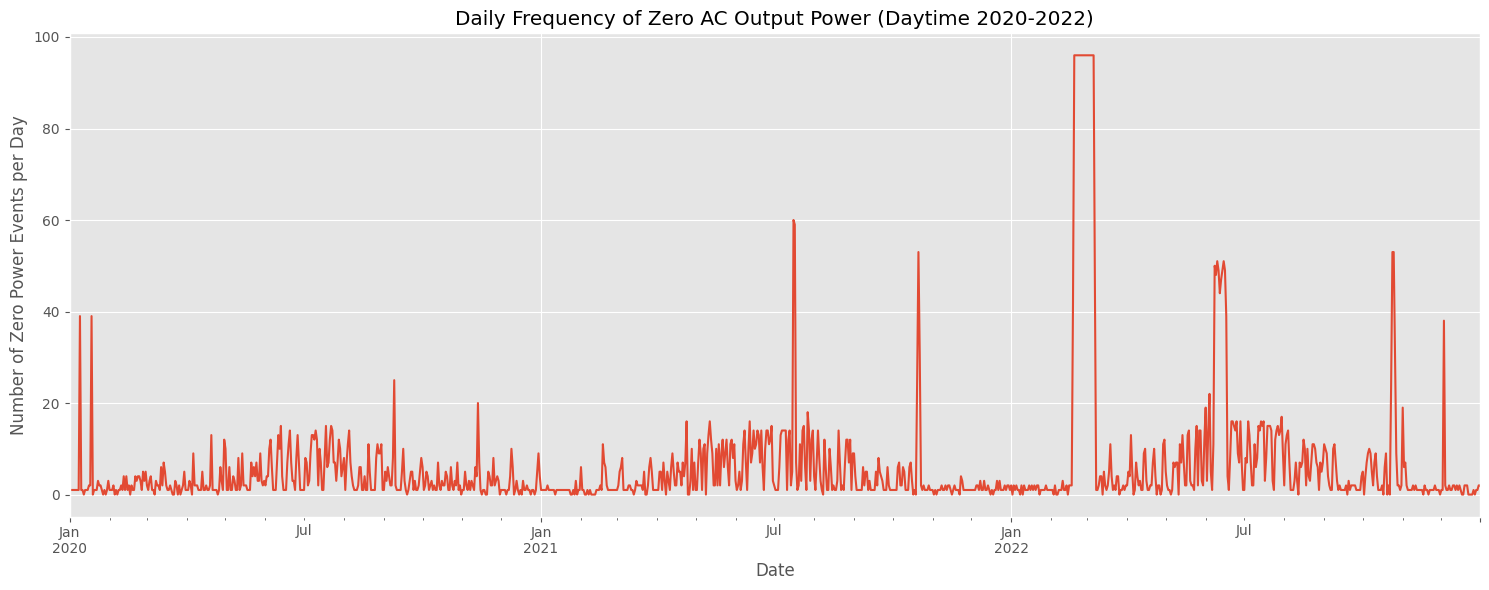

Total zero AC output power events during daytime (2020-2022): 6732 at 15-minute intervals.
Maximum daily zero power events: 96 (This means up to 24.0 hours of zero power on a single day).


The Daily Frequency of Zero AC Output Power plot shows how often the solar system recorded zero power events during daytime between 2020 and 2022. Most days have only a few such events, but occasional spikes indicate periods where the system repeatedly produced no power, which may suggest cloud cover, temporary system faults, sensor issues, or maintenance periods.

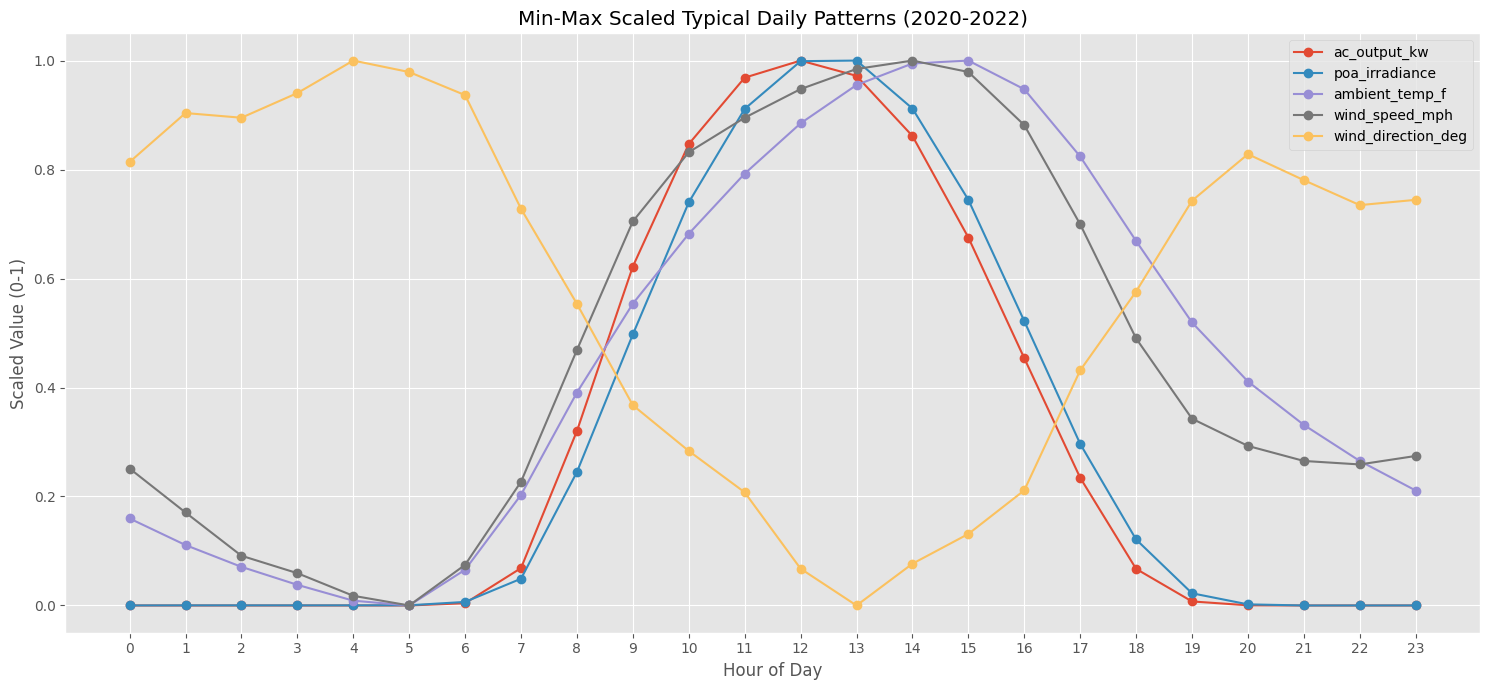

The Min-Max Scaled Typical Daily Patterns plot shows how different environmental variables and solar power output change throughout a typical day. Both POA irradiance and AC power output rise in the morning, peak around midday, and decline toward evening, reflecting the daily solar production cycle. Other variables such as ambient temperature and wind speed follow smoother daily patterns, while wind direction varies more independently across the day.

<br>Exploratory Data Analysis revealed strong temporal structure and variability within the solar power dataset. The time-series visualization shows a clear cyclical pattern driven by solar position, with consistent daytime peaks and low-output periods occurring during early and late daylight hours. However, the data also exhibits irregular fluctuations around peak production, reflecting the influence of transient weather conditions such as cloud cover and atmospheric changes. This variability highlights the dynamic nature of solar generation and reinforces the need for models capable of capturing both seasonal patterns and short-term volatility.

---
## Limitations

* **Data Dependency and Quality**<br>
  Deep neural networks (DNNs) rely heavily on large volumes of high-quality data. Any missing values, sensor errors, or inconsistencies in the PVDAQ dataset can negatively impact model performance and generalization.

* **Limited Interpretability**<br>
  DNNs function as “black-box” models, making it difficult to explain how input features (e.g., irradiance, temperature) influence predictions. This limits transparency compared to simpler models and may reduce trust in operational settings.

* **Overfitting Risk**<br>
  Due to their high capacity, DNNs are prone to overfitting, especially when trained on limited time spans (e.g., 2020–2021). This may reduce performance when generalizing to unseen data such as the 2022 test set.

* **Computational Complexity**<br>
  Training deep neural networks requires significant computational resources and time, particularly for hyperparameter tuning. This can be a limitation when working in constrained environments (e.g., free-tier cloud platforms).

* **Temporal Generalization Challenges**<br>
  Solar power data exhibits strong seasonality and non-stationarity. A model trained on past years may struggle to adapt to changing weather patterns or system behavior over time.

* **Limited Feature Scope**<br>
  The model primarily relies on historical and meteorological variables. The absence of external data sources (e.g., real-time weather forecasts, cloud cover imagery) may restrict predictive accuracy.

* **Lack of Model Diversity**<br>
  Using only deep neural networks excludes comparison with alternative approaches (e.g., XGBoost, SARIMAX, persistence baselines), limiting insight into whether DNNs are the most effective choice for this problem.

---
## Future Work

* **Incorporate Additional Weather Data**<br>
  Integrate external weather sources (e.g., cloud cover, humidity, and wind forecasts) to improve model accuracy and robustness under varying environmental conditions.

* **Advanced Model Development**<br>
  Explore deep learning models such as LSTM or Temporal Fusion Transformers (TFT) to better capture temporal dependencies in solar power generation.

* **Ensemble Learning**<br>
  Combine multiple models (e.g., persistence, XGBoost, and neural networks) to create a more stable and accurate forecasting system.

* **Anomaly Detection Integration**<br>
  Implement residual-based anomaly detection to identify unusual patterns or system faults in solar power output.

* **Real-Time Deployment**<br>
  Develop a production pipeline using live data feeds and APIs to enable real-time solar forecasting and monitoring.

* **Cross-System Generalization**<br>
  Validate models across multiple PV systems (e.g., 2105 and 2107) to ensure scalability and generalization.

* **Feature Engineering Enhancements**<br>
  Incorporate solar geometry features and more advanced lag/rolling statistics to capture temporal and seasonal patterns more effectively.


---
## Conclusions

### Weight Initialization Conclusion

During weight initialization experiment the model B — ReLU with He
initialization demonstrates better generalization and achieves the lowest
validation loss, making it the stronger model for forecasting unseen solar
power data compared to ReLu default initializer. Although Model A fits the
training data more tightly (lower training loss), Model B learns faster in early
epochs and ultimately predicts new data more accurately. This aligns with
theory: He initialization is specifically optimized for ReLU networks, and
your results confirm its advantage in practice.

### Activation Functions in Deep Neural Networks

Over the course of the ten training epochs, all of the activation functions
improved, but some were obviously more effective than others. As a
baseline, ReLU worked well, but functions that handle negative values
more smoothly, such as Leaky ReLU and particularly ELU, learned more
quickly and produced lower validation errors. With the lowest MAE and the
most consistent training behavior, ELU was clearly the best overall. The
mixed ReLU+ELU model offered no significant advantage, and SELU
performed passably but fell short of ELU. For this model and dataset, ELU
was the best option overall.

### Optimizers Comparison in DNN
Across all optimizers tested, there was a clear performance gap between
the basic SGD variants and adaptive optimizers. Adding Momentum to
SGD noticeably improved smoothness and accuracy compared to plain
SGD, while Nesterov showed similar but slightly weaker results in this
setup. RMSProp emerged as the top performer overall, achieving the
lowest validation MAE due to its dynamic learning rate adaptation.
AdaGrad struggled because its learning rate decayed too quickly, leading
to early stagnation. Within the Adam family, both Adam and AdamW
consistently delivered strong results with similar final MAE values,
outperforming Nadam and Adamax. Overall, RMSProp and Adam-style
optimizers offered the best balance of speed and accuracy for this
forecasting task.

---
## Appendix

### A. Notebooks

All data preparation, analysis, and visualization were performed using 2 separate Jupyter notebooks. Each step described in the report corresponds directly to it's structure. These notebooks contain the full implementation.

### B. Data Source

The dataset used in this study is obtained from the National Renewable Energy Laboratory through the PVDAQ (Photovoltaic Data Acquisition) system. PVDAQ provides high-resolution, real-world solar power generation data collected from multiple photovoltaic installations, including detailed measurements of irradiance, temperature, and AC power output. This dataset is widely used for benchmarking solar forecasting models due to its rich temporal structure and realistic operational variability.

Data Source - https://data.openei.org/submissions/4568

### C. References

1. National Renewable Energy Laboratory. *PVDAQ: Photovoltaic Data Acquisition System Dataset*. Available: [https://data.openei.org/submissions/4568](https://data.openei.org/submissions/4568)

2. Open Energy Data Initiative. *Solar Data Prize Dataset (Systems 2105 & 2107)*. Available: [https://data.openei.org](https://data.openei.org)

3. National Oceanic and Atmospheric Administration. *Global Historical Climatology Network (GHCN)*. Available: [https://www.ncdc.noaa.gov/ghcn](https://www.ncdc.noaa.gov/ghcn)

4. University of California Irvine. *Electricity Load Diagrams Dataset*. Available: [https://archive.ics.uci.edu](https://archive.ics.uci.edu)

5. Aurélien Géron. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, 3rd ed., O’Reilly Media, 2022

6. Kaggle. *Solar Power Forecasting Notebook by Ali Assad Beiki*. Available: [https://www.kaggle.com/code/aliassadbeiki/solar-power-forecasting](https://www.kaggle.com/code/aliassadbeiki/solar-power-forecasting)

7. Scikit-learn. *Machine Learning in Python: Documentation and User Guide*. Available: [https://scikit-learn.org](https://scikit-learn.org)

8. XGBoost. *Extreme Gradient Boosting: Scalable Tree Boosting System*. Available: [https://xgboost.readthedocs.io](https://xgboost.readthedocs.io)

9. Google. *TensorFlow: Large-Scale Machine Learning on Heterogeneous Systems*. Available: [https://www.tensorflow.org](https://www.tensorflow.org)

10. International Energy Agency. *Renewables 2023: Solar PV Market Analysis*. Available: [https://www.iea.org](https://www.iea.org)


---
<div style="text-align: right; margin-top: 40px;">
<strong>Geronimo Welter Lapinig</strong> &nbsp;&nbsp; <strong>Victor Rusu</strong> &nbsp;&nbsp; <strong>Sankruththian Senathirajah</strong><br>
University of Toronto School of Continuing Studies<br>
April 2026
</div>